# SECP3223 Final Exam Solution
**Name**: Nurul Adriana Binti Kamal Jefri  
**Matric No**: A23CS0258  

---

## Question 1

In [17]:
import pandas as pd

# 1. Create a hierarchical index Series
data = pd.Series(
    [320, 450, 390, 670, 230, 510],
    index=[
        ['North', 'North', 'South', 'South', 'East', 'East'],
        ['A', 'B', 'A', 'B', 'A', 'B']
    ]
)

# 2. Rename index levels and column
data.index.names = ['Region', 'Sub-region']
data.name = 'Sales'

# 3. Retrieve all sales for South region
south_sales = data.loc['South']

# 4. Total sales per region
region_total = data.groupby(level='Region').sum()

# 5. Total sales per sub-region
subregion_total = data.groupby(level='Sub-region').sum()

# 6. Convert to DataFrame
df = data.reset_index()

# 7. Sort by Sales in descending order
sorted_sales = data.sort_values(ascending=False)

# Displaying results in tables
print("Hierarchical Series:")
print(data.to_frame().to_markdown())
print("\nSouth Region Sales:")
print(south_sales.to_frame().to_markdown())
print("\nTotal Sales by Region:")
print(region_total.to_frame().to_markdown())
print("\nTotal Sales by Sub-region:")
print(subregion_total.to_frame().to_markdown())
print("\nConverted DataFrame:")
print(df.to_markdown(index=False))
print("\nSorted Sales (Descending):")
print(sorted_sales.to_frame().to_markdown())

Hierarchical Series:
|                |   Sales |
|:---------------|--------:|
| ('North', 'A') |     320 |
| ('North', 'B') |     450 |
| ('South', 'A') |     390 |
| ('South', 'B') |     670 |
| ('East', 'A')  |     230 |
| ('East', 'B')  |     510 |

South Region Sales:
| Sub-region   |   Sales |
|:-------------|--------:|
| A            |     390 |
| B            |     670 |

Total Sales by Region:
| Region   |   Sales |
|:---------|--------:|
| East     |     740 |
| North    |     770 |
| South    |    1060 |

Total Sales by Sub-region:
| Sub-region   |   Sales |
|:-------------|--------:|
| A            |     940 |
| B            |    1630 |

Converted DataFrame:
| Region   | Sub-region   |   Sales |
|:---------|:-------------|--------:|
| North    | A            |     320 |
| North    | B            |     450 |
| South    | A            |     390 |
| South    | B            |     670 |
| East     | A            |     230 |
| East     | B            |     510 |

Sorted Sales (De

## Question 2

In [19]:
# Load datasets
pop = pd.read_csv("state-population.csv")
areas = pd.read_csv("state-areas.csv")
abbrevs = pd.read_csv("state-abbrevs.csv")

# Display top 5 rows in tables
print("Population Data (first 5 rows):")
print(pop.head().to_markdown())
print("\nArea Data (first 5 rows):")
print(areas.head().to_markdown())
print("\nAbbreviation Data (first 5 rows):")
print(abbrevs.head().to_markdown())

# Merge pop with abbrevs
merged = pd.merge(pop, abbrevs, how='left', left_on='state/region', right_on='abbreviation')

# Remove duplicated or unnecessary columns
merged = merged.drop(columns=['abbreviation'])

# Check for missing values
missing_cols = merged.columns[merged.isnull().any()].tolist()
merged_clean = merged.dropna()

# Merge with areas
final = pd.merge(merged_clean, areas, how='left', on='state')

# Display top 5 rows of final
final = final.dropna()
print("\nMerged Final Data (first 5 rows):")
print(final.head().to_markdown())

# Filter for 2010 and total ages
Data2010 = final.query("year == 2010 and ages == 'total'")

# Set state as index
Data2010 = Data2010.set_index('state')

# Calculate population density
Data2010['density'] = Data2010['population'] / Data2010['area (sq. mi)']

# Sort by density
sorted_density = Data2010['density'].sort_values(ascending=False)

# Top 5 least densely populated states
least_dense = sorted_density.tail(5)

# Display results in tables
print("\n2010 Data with Density (sorted by density, first 5 rows):")
print(Data2010[['population', 'area (sq. mi)', 'density']]
      .sort_values(by='density', ascending=False)
      .head()
      .to_markdown())

print("\nTop 5 Least Densely Populated States:")
print(least_dense.to_frame().to_markdown())

Population Data (first 5 rows):
|    | state/region   | ages    |   year |   population |
|---:|:---------------|:--------|-------:|-------------:|
|  0 | AL             | under18 |   2012 |  1.11749e+06 |
|  1 | AL             | total   |   2012 |  4.81753e+06 |
|  2 | AL             | under18 |   2010 |  1.13097e+06 |
|  3 | AL             | total   |   2010 |  4.78557e+06 |
|  4 | AL             | under18 |   2011 |  1.12576e+06 |

Area Data (first 5 rows):
|    | state      |   area (sq. mi) |
|---:|:-----------|----------------:|
|  0 | Alabama    |           52423 |
|  1 | Alaska     |          656425 |
|  2 | Arizona    |          114006 |
|  3 | Arkansas   |           53182 |
|  4 | California |          163707 |

Abbreviation Data (first 5 rows):
|    | state      | abbreviation   |
|---:|:-----------|:---------------|
|  0 | Alabama    | AL             |
|  1 | Alaska     | AK             |
|  2 | Arizona    | AZ             |
|  3 | Arkansas   | AR             |
|  4 | Calif

## Question 3

In [21]:
# Load employee performance dataset
emp_perf = pd.read_csv("employee_performance_data.csv", index_col='Employee_ID')
emp_details = pd.read_csv("employee_details.csv")

# Filter employees from Sales with Performance_Score > 4
filtered_emp = emp_perf[(emp_perf['Department'] == 'Sales') & (emp_perf['Performance_Score'] > 4)]

# Merge performance with details
merged_emp = pd.merge(emp_perf.reset_index(), emp_details, on='Employee_ID')

# High salary employees
high_salary_employees = merged_emp[merged_emp['Monthly_Salary'] > 4500]

# Email list
email_list = high_salary_employees['Email'].tolist()

# Sort by Department and Performance_Score
sorted_merged = merged_emp.sort_values(by=['Department', 'Performance_Score'], ascending=[True, False])

# Reorder columns
ordered_columns = ['Name', 'Department', 'Monthly_Salary', 'Performance_Score', 'Email', 'Phone_Number']
sorted_merged = sorted_merged[ordered_columns]

# Calculate Years Since Last Promotion
merged_emp['Years_Since_Last_Promotion'] = 2024 - merged_emp['Last_Promotion_Year']

# Promotion status
def get_promo_status(row):
    if row['Years_Since_Last_Promotion'] <= 2:
        return "Recently Promoted"
    elif row['Years_Since_Last_Promotion'] > 5 and row['Performance_Score'] >= 4:
        return "Due for Promotion"
    else:
        return "No Promotion Needed"

merged_emp['Promotion_Status'] = merged_emp.apply(get_promo_status, axis=1)

# Display results in tables
print("=== High Performing Sales Employees ===")
print(filtered_emp.to_markdown())
print("\n")

print("=== Email List of High Salary Employees ===")
print(pd.DataFrame(email_list, columns=['Email']).to_markdown(index=False))
print("\n")

print("=== Employees Sorted by Department and Performance ===")
print(sorted_merged.head().to_markdown(index=False))
print("\n")

print("=== Promotion Analysis ===")
print(merged_emp[['Name', 'Years_Since_Last_Promotion', 'Promotion_Status']].head().to_markdown(index=False))

=== High Performing Sales Employees ===
|   Employee_ID | Name        | Department   |   Monthly_Salary |   Years_at_Company |   Performance_Score |   Last_Promotion_Year | Work_Location   |
|--------------:|:------------|:-------------|-----------------:|-------------------:|--------------------:|----------------------:|:----------------|
|           112 | Employee 12 | Sales        |             6566 |                  5 |                 5   |                  2021 | Rural           |
|           118 | Employee 18 | Sales        |             5184 |                  6 |                 5   |                  2019 | Rural           |
|           120 | Employee 20 | Sales        |             6462 |                  1 |                 4.1 |                  2016 | Rural           |
|           125 | Employee 25 | Sales        |             3282 |                 15 |                 4.2 |                  2023 | Urban           |
|           128 | Employee 28 | Sales        |        

## Question 4

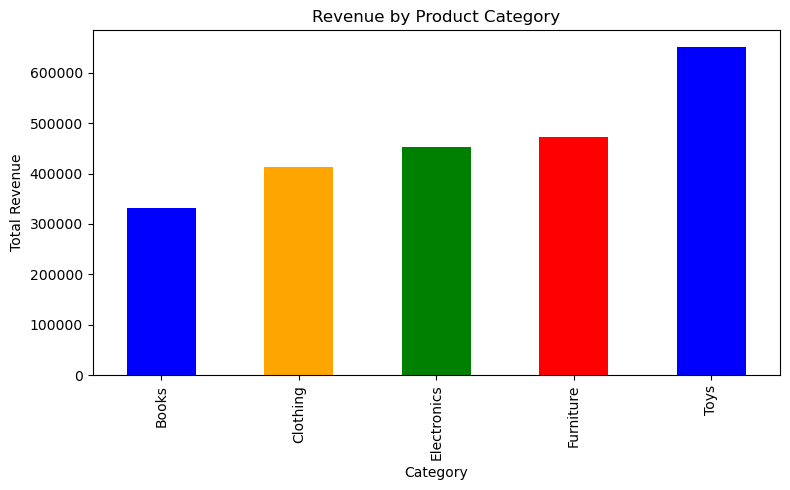

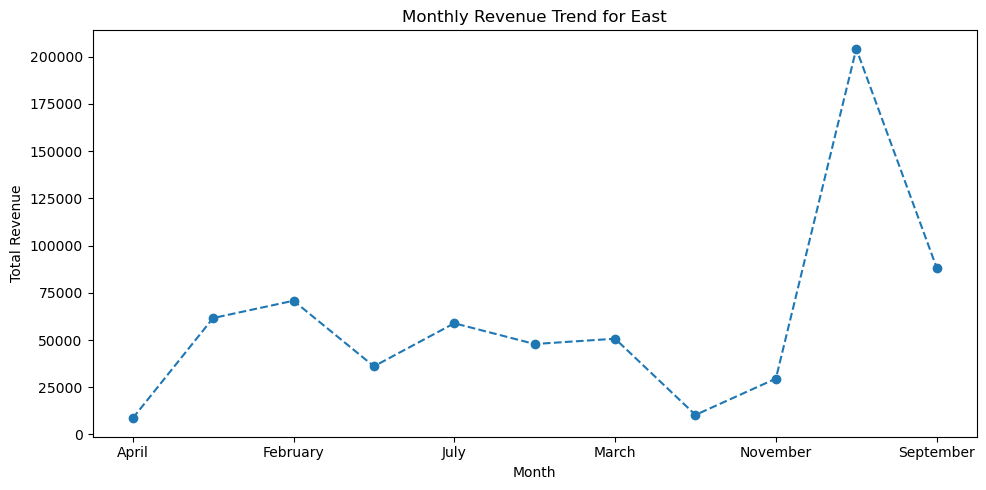

('Q4', 'Q1')

In [23]:
# Add this to the very top of your notebook or before Question 4
%matplotlib inline
import matplotlib.pyplot as plt

# Load dataset
sales = pd.read_csv("products_sales.csv")

# Total revenue by category
category_revenue = sales.groupby('Category')['Revenue'].sum()

# Bar chart
plt.figure(figsize=(8, 5))
category_revenue.plot(kind='bar', color=['blue', 'orange', 'green', 'red'])
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

# Highest category
highest_revenue_category = category_revenue.idxmax()
revenue_diff = category_revenue.max() - category_revenue.min()

# Monthly revenue trend for top region
top_region = sales.groupby('Region')['Revenue'].sum().idxmax()
monthly_revenue = sales[sales['Region'] == top_region].groupby('Month')['Revenue'].sum()

# Line plot
plt.figure(figsize=(10, 5))
monthly_revenue.plot(marker='o', linestyle='--')
plt.title(f"Monthly Revenue Trend for {top_region}")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

# Quarter analysis
month_to_qtr = {
    'January': 'Q1', 'February': 'Q1', 'March': 'Q1',
    'April': 'Q2', 'May': 'Q2', 'June': 'Q2',
    'July': 'Q3', 'August': 'Q3', 'September': 'Q3',
    'October': 'Q4', 'November': 'Q4', 'December': 'Q4'
}
sales['Quarter'] = sales['Month'].map(month_to_qtr)
qtr_revenue = sales.groupby('Quarter')['Revenue'].sum()
qtr_revenue.idxmax(), qtr_revenue.idxmin()
